In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.shape

(150, 6)

In [4]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
X = df.iloc[:,:-1]
y = df[['Species']]

In [7]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,random_state = 42,test_size = 0.2,stratify = y)

In [8]:
scale = StandardScaler()

In [9]:
xtrain = scale.fit_transform(xtrain)

In [10]:
xtest = scale.transform(xtest)

In [11]:
rmodel = RandomForestClassifier(n_estimators = 100, random_state = 42)

In [12]:
rmodel.fit(xtrain,ytrain)

C:\Users\papli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [13]:
ypred = rmodel.predict(xtest)

In [14]:
accuracy = accuracy_score(ytest,ypred)

In [15]:
print('Accuracy score:',accuracy*100,'%')

Accuracy score: 100.0 %


In [16]:
print('\nClassification report:')
print(classification_report(ytest,ypred))


Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



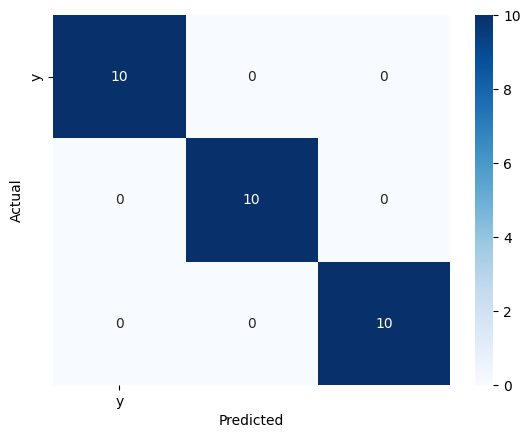

In [21]:
cm = confusion_matrix(ytest,ypred)
sns.heatmap(cm,annot=True,cmap = 'Blues',xticklabels = 'auto',yticklabels = 'y')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()